<a href="https://colab.research.google.com/github/lakshuu-jay/Projects/blob/main/DataTransformationAndDataAssociation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64
Genre has only two categories: Fiction and Non Fiction
No categories need to be combined.
   User Rating Rating Category
0          4.7       Excellent
1          4.6       Excellent
2          4.7       Excellent
3          4.7       Excellent
4          4.8       Excellent
Skewness:
User Rating   -1.502125
Reviews        2.421597
Price          3.685057
Year           0.000000
dtype: float64
Contingency Table:
Genre            Fiction  Non Fiction
Rating Category                      
Good                  58          100
Excellent            182          210
Chi-Square: 3.939369027393523
P-Value: 0.047168466288826816
User Rating and Genre are associated.
Correlation between User Rating and Price: -0.13308628728087976
User Rating and Price have a weak association.


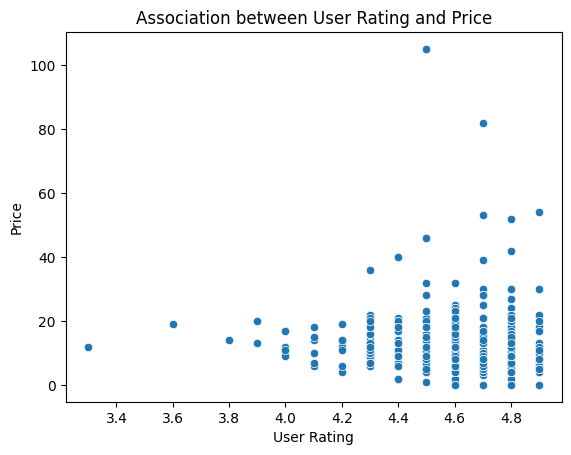

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

data = pd.read_csv('Bestsellers with categories.csv')

data.head()

data.isnull().sum()

data = data.dropna()

print(data['Genre'].value_counts())

print("Genre has only two categories: Fiction and Non Fiction")
print("No categories need to be combined.")

data['Rating Category'] = pd.cut(
    data['User Rating'],
    bins=[0, 4.5, 5],
    labels=['Good', 'Excellent']
)

print(data[['User Rating', 'Rating Category']].head())

numerical_data = data.select_dtypes(include='number')

print("Skewness:")
print(numerical_data.skew())

table = pd.crosstab(data['Rating Category'], data['Genre'])

print("Contingency Table:")
print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("P-Value:", p)

if p < 0.05:
    print("User Rating and Genre are associated.")
else:
    print("User Rating and Genre are not associated.")

correlation = data['User Rating'].corr(data['Price'])

print("Correlation between User Rating and Price:", correlation)

if abs(correlation) < 0.3:
    print("User Rating and Price have a weak association.")
else:
    print("User Rating and Price have a strong association.")

sns.scatterplot(x=data['User Rating'], y=data['Price'])
plt.xlabel('User Rating')
plt.ylabel('Price')
plt.title('Association between User Rating and Price')
plt.show()